Graphical results notebook for matrix multiplication benchmarking in Python using mlx, numpy, and pure python implementations.

In [1]:
from multiply.payloads import multiply_at_size
import numpy as np

In [2]:
from multiply.matrix_factory import random_matrix, stack_matrices

In [3]:
from multiply.multiply import matmul
from multiply.array_abstraction import clear_gpu_cache

In [4]:
def data_for_engine(engine, limit):
    sizes = 2**np.arange(1, limit, 0.5)
    def matmul_for_engine(size):
        return matmul(size, engine)
    times = np.vectorize(matmul_for_engine)(sizes.astype(int))
    clear_gpu_cache()
    return np.vstack([sizes, times])

In [5]:
limits = {
    'python': 9,
    'numpy': 13,
    'numba': 10,
    'torch-cpu': 13,
    'cupy': 14.5,
    'jax-cpu': 13,
    'jax-gpu': 14.5,
    'torch-gpu': 14.5,
}


In [6]:
data = {engine: data_for_engine(engine, limit) for engine, limit in limits.items()}
data

E0402 22:42:45.644908  245180 xtile_compiler.cc:399] Fusion: gemm_fusion_dot_general.1 = f32[90,90]{1,0} fusion(a.1, b.1), kind=kCustom, calls=gemm_fusion_dot_general.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["128","256"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0402 22:42:45.645008  245180 xtile_compiler.cc:401] Computation: gemm_fusion_dot_general.1_computation.clone {
  parameter_0 = f32[90,90]{1,0} parameter(0)
  parameter_1 = f32[90,90]{1,0} parameter(1)
  ROOT dot_general.0 = f32[90,90]{1,0} dot(parameter_0, parameter_1), lhs_contracting_dims={1}, rhs_contracting_dims={0}, backend_config={"sizes":["32"]}
}
E0402 22:42:45.891571  245179 xtile_compiler.cc:399]

{'python': array([[2.00000000e+00, 2.82842712e+00, 4.00000000e+00, 5.65685425e+00,
         8.00000000e+00, 1.13137085e+01, 1.60000000e+01, 2.26274170e+01,
         3.20000000e+01, 4.52548340e+01, 6.40000000e+01, 9.05096680e+01,
         1.28000000e+02, 1.81019336e+02, 2.56000000e+02, 3.62038672e+02],
        [1.66165992e-05, 1.07903965e-05, 4.35342081e-05, 7.74316024e-05,
         2.16242007e-04, 4.82220598e-04, 8.57313199e-04, 1.45347101e-03,
         2.98127960e-03, 7.64254200e-03, 2.06229290e-02, 5.75016040e-02,
         1.78960536e-01, 4.10173348e-01, 1.04016404e+00, 2.94012805e+00]]),
 'numpy': array([[2.00000000e+00, 2.82842712e+00, 4.00000000e+00, 5.65685425e+00,
         8.00000000e+00, 1.13137085e+01, 1.60000000e+01, 2.26274170e+01,
         3.20000000e+01, 4.52548340e+01, 6.40000000e+01, 9.05096680e+01,
         1.28000000e+02, 1.81019336e+02, 2.56000000e+02, 3.62038672e+02,
         5.12000000e+02, 7.24077344e+02, 1.02400000e+03, 1.44815469e+03,
         2.04800000e+03, 2.8

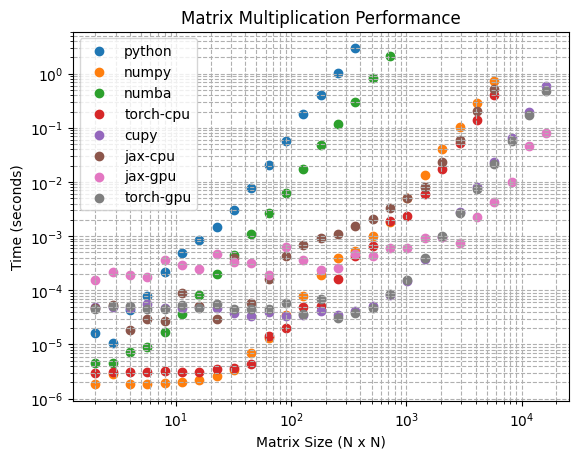

In [7]:
import matplotlib.pyplot as plt
for engine, engine_data in data.items():
    plt.scatter(*engine_data, label=engine)
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Matrix Size (N x N)')
plt.ylabel('Time (seconds)')
plt.title('Matrix Multiplication Performance')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

In [8]:

#Model the data as a power law plus a constant
def model_function(x, a, b, c):
    return np.log(c + a * x ** b)

from scipy.optimize import curve_fit


In [10]:
seeds = {
    'python': [4e-9, 3, 1e-4],
    'numpy': [4e-9, 3, 1e-4],
    'numba': [4e-9, 3, 1e-4],
    'cupy': [4e-9, 3, 1e-4],
    'jax-cpu': [4e-9, 3, 1e-4],
    'jax-gpu': [4e-9, 3, 1e-4],
    'torch-cpu': [4e-9, 3, 1e-4],
    'torch-gpu': [4e-9, 3, 1e-4],
}

params_for_engine = {
    engine: curve_fit(
        model_function,
        engine_data[0],
        np.log(engine_data[1]),
        p0=seeds[engine],
        bounds=([0, 0, 0], [np.inf, np.inf, np.inf])
    )[0]
    for engine, engine_data in data.items()
}
params_for_engine

{'python': array([7.05288326e-07, 2.53697803e+00, 9.31599608e-06]),
 'numpy': array([1.82783040e-09, 2.18796878e+00, 1.94970564e-06]),
 'numba': array([4.61880069e-08, 2.66188139e+00, 4.39737814e-06]),
 'torch-cpu': array([1.48054020e-09, 2.08663667e+00, 2.73709987e-06]),
 'cupy': array([1.02203008e-09, 1.87370487e+00, 3.77286007e-05]),
 'jax-cpu': array([1.51143280e-07, 1.60999407e+00, 3.78821095e-05]),
 'jax-gpu': array([2.37609075e-09, 1.70001212e+00, 2.80074340e-04]),
 'torch-gpu': array([7.76900969e-10, 1.90207796e+00, 4.56862234e-05])}

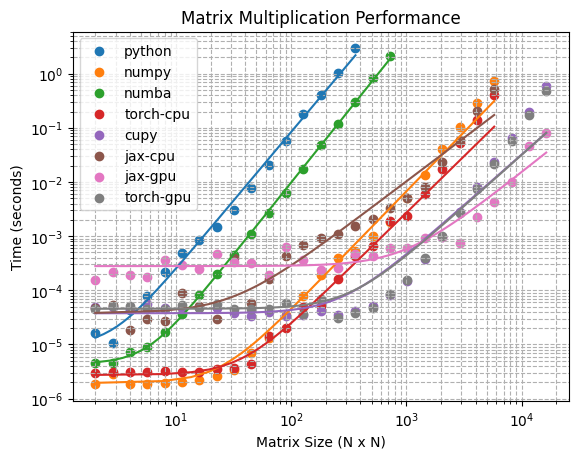

In [11]:
# Plot with a fit

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Matrix Size (N)')
plt.ylabel('Time (seconds)')
plt.title('Matrix Multiplication Time vs Size')
plt.xlabel('Matrix Size (N x N)')
plt.ylabel('Time (seconds)')
plt.title('Matrix Multiplication Performance')
plt.grid(True, which="both", ls="--")

def plot_with_fit(data, model, fit, label):
    x_fit = np.linspace(data[0].min(), data[0].max(), 1000)
    y_fit = np.exp(model(x_fit, *fit))
    plt.scatter(*data, marker='o', label=label)
    plt.plot(x_fit, y_fit)

for engine, engine_data in data.items():
    fit_params = params_for_engine[engine]
    plot_with_fit(engine_data, model_function, fit_params, engine)

plt.legend()
plt.show()